In [410]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from pydantic import Field, BaseModel

In [411]:
load_dotenv()
model = ChatGroq(model="openai/gpt-oss-20b")

In [412]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description="Sentiment of the review")

In [413]:
structured_model = model.with_structured_output(SentimentSchema)

In [414]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(
        description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(
        description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(
        description='How urgent or critical the issue appears to be')

In [415]:
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [416]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    response: str
    diagnosis: dict

In [417]:
def find_sentiment(state: ReviewState):
    prompt = f"For the following review find out the sentiment \n {state['review']}"
    sentiment = structured_model.invoke(prompt).sentiment
    return {"sentiment": sentiment}

In [418]:
def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {'response': response}

In [419]:
def negative_response(state: ReviewState):
    diagnosis = state["diagnosis"]
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content
    return {'response': response}

In [ ]:
def neg_sentiment_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)
    
    return {'diagnosis': response.model_dump()}

In [421]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "neg_sentiment_diagnosis"]:
    sentiment = state['sentiment']
    if sentiment == "Positive":
        return "positive_response"
    else:
        return "neg_sentiment_diagnosis"

In [422]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("neg_sentiment_diagnosis", neg_sentiment_diagnosis)
graph.add_node("positive_response", positive_response)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('neg_sentiment_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow =  graph.compile()

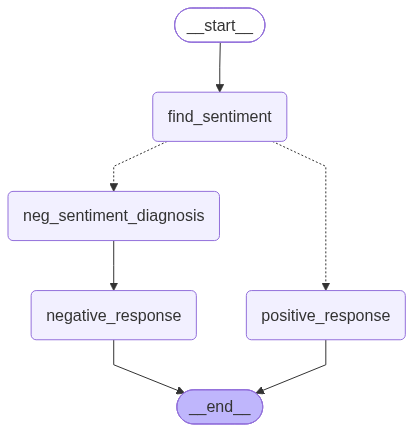

In [423]:
workflow

In [424]:
intial_state = {
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'response': 'Hi there,\n\nI’m really sorry you’re running into this issue—sounds like it’s been a hassle, and I totally understand why you’re frustrated. Let’s get this sorted out as quickly as possible.\n\n### What we’ll do next\n\n1. **Quick sanity check**  \n   * Make sure you’re running the latest version of the app (or browser) – we’ve released a patch that fixes a similar bug.  \n   * Clear your cache or try a private/incognito window to rule out any local data issues.\n\n2. **Reproduce the problem**  \n   * Could you let me know the exact steps you’re taking when the bug appears?  \n   * A screenshot or a short screen‑record (if you’re comfortable sharing) would be super helpful.\n\n3. **Log details**  \n   * If